# 1. Data preprocessing and curation

This notebook focuses on the preparation of LPS datasets, including both public and private sources, and demonstrates how to merge them for training the PerturbGen model.

## 1.1. Public LPS data

Import Libraries

In [4]:
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sns

/u/asachan/.cache/pypoetry/virtualenvs/perturbgen-GRq9_bGO-py3.12/lib/python3.12/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/u/asachan/.cache/pypoetry/virtualenvs/perturbgen-GRq9_bGO-py3.12/lib/python3.12/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/u/asachan/.cache/pypoetry/virtualenvs/perturbgen-GRq9_bGO-py3.12/lib/python3.12/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/u/asachan/.cache/pypoetry/virtualenvs/perturbgen-GRq9_bGO-py3.12/lib/python3.12/site-packages/leidenalg/Optimiser.py:346: SyntaxWar

In [5]:
# Read the downloaded h5ad file
adata = sc.read('/projects/bgdb/asachan/datasets/perturbgen_tut/covid_portal_210320_with_raw.h5ad')

Here, we investigate the .h5ad file to identify LPS samples and healthy control cells in the downloaded LPS data.

In [6]:
adata

AnnData object with n_obs × n_vars = 647366 × 24929
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id'
    var: 'feature_types'
    uns: 'hvg', 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'raw'

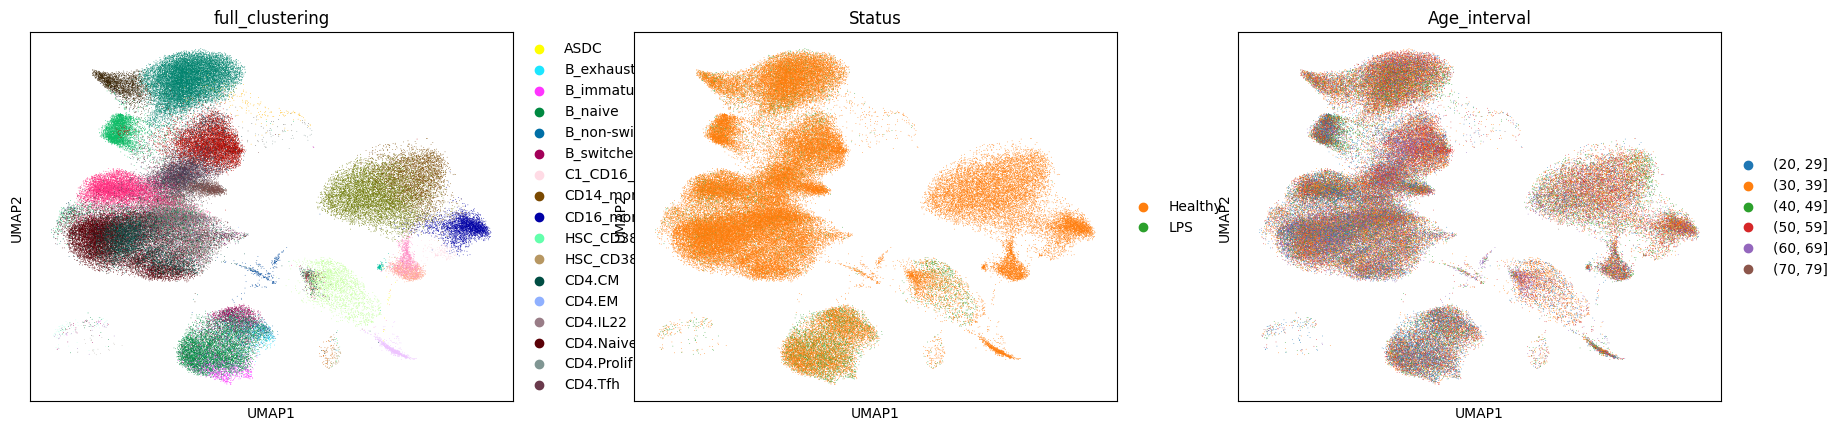

In [19]:
sc.pl.umap(adata, color=['full_clustering', 'Status', 'Age_interval'])

In [10]:
adata.obs['time_after_LPS'].value_counts() # check time points available

time_after_LPS
nan    639482
90m      3999
10h      3885
Name: count, dtype: int64

In [8]:
adata.obs['Status'].value_counts() # check conditions available

Status
Covid        527286
Healthy       97039
Non_covid     15157
LPS            7884
Name: count, dtype: int64

In [11]:
lps_sample_ids = adata.obs.loc[adata.obs['Status'] == 'LPS', 'patient_id'].unique() # get patient ids for LPS samples

healthy_sample_ids = adata.obs.loc[adata.obs['Status'] == 'Healthy', 'patient_id'].unique() # get patient ids for Healthy samples

In [12]:
adata = adata[adata.obs['Status'].isin(['LPS','Healthy'])].copy() # keep only LPS and Healthy samples

Next, we apply a set of modifications and add details to make downstream analyses more convenient e.g. converting time obs into categorical obs

In [13]:
adata.obs['time_after_LPS'] = adata.obs['time_after_LPS'].astype(str) # convert to string
adata.obs['time_after_LPS'] = adata.obs['time_after_LPS'].replace('nan', 'normal') # replace nan with normal

In [14]:
adata.obs['time_after_LPS'] = adata.obs['time_after_LPS'].apply(lambda x: x if x == 'normal' else f'{x}_LPS')

adata.obs['time_after_LPS'] = pd.Categorical(
    adata.obs['time_after_LPS'],
    categories=['normal', '90m_LPS', '10h_LPS'],
    ordered=True
)

In [15]:
adata.obs['time_after_LPS'].value_counts()

time_after_LPS
normal     97039
90m_LPS     3999
10h_LPS     3885
Name: count, dtype: int64

In [16]:
adata.obs['donor_id'] = adata.obs['patient_id']

In [17]:
adata.obs['study'] = 'Public_Emily2021'

In [18]:
adata.obs['Age_interval'].value_counts()

Age_interval
(30, 39]    30538
(50, 59]    26344
(20, 29]    20426
(40, 49]    15926
(60, 69]     9970
(70, 79]     1719
Name: count, dtype: int64

In [20]:
mapping = {
    '(20, 29]': 'Adult',      
    '(30, 39]': 'Adult',
    '(40, 49]': 'Adult',
    '(50, 59]': 'Adult',
    '(60, 69]': 'Adult',
    '(70, 79]': 'Old'
}


In [21]:
adata.obs['life_stage'] = adata.obs['Age_interval'].map(mapping)


adata.obs['life_stage'] = pd.Categorical(
    adata.obs['life_stage'],
    categories=['Embryo', 'Fetal', 'Childhood', 'Young Adult', 'Adult', 'Old'],
    ordered=True
)


In [22]:
adata.obs['development_stage'] = adata.obs['life_stage']

In [23]:
adata.obs['tissue'] = 'blood'

In [24]:
adata.X = adata.layers['raw'].copy()

In [25]:
adata.X.max()

np.float32(275279.0)

In [26]:
adata.obs['Resample']

covid_index
AAACCTGAGACCACGA-newcastle65    Initial
AAACCTGAGATGTCGG-newcastle65    Initial
AAACCTGAGGCGATAC-newcastle65    Initial
AAACCTGAGTACACCT-newcastle65    Initial
AAACCTGAGTGAATTG-newcastle65    Initial
                                 ...   
BGCV15_TTTCCTCTCTGATACG-1       Initial
BGCV15_TTTCCTCTCTTTAGGG-1       Initial
BGCV15_TTTGCGCTCACCGTAA-1       Initial
BGCV15_TTTGGTTTCAAGATCC-1       Initial
BGCV15_TTTGTCACAAGCCATT-1       Initial
Name: Resample, Length: 104923, dtype: category
Categories (1, object): ['Initial']

In [27]:
# Subset to Gene Expression features
adata = adata[:, adata.var['feature_types'] == 'Gene Expression']


In [34]:
ref = pd.read_csv(
    "/projects/bgdb/asachan/datasets/perturbgen_tut/genome_files/mart_export.txt",
    sep="\t"
)
print(ref.columns.tolist())  # should now show ['Gene stable ID', 'Gene name']

['Gene stable ID', 'Gene name']


In [35]:
ref = ref.rename(columns={"Gene name": "HGNC symbol"})
print(ref.columns.tolist())  # ['Gene stable ID', 'HGNC symbol']

['Gene stable ID', 'HGNC symbol']


In [30]:
adata.var

,feature_types
MIR1302-2HG,Gene Expression
AL627309.1,Gene Expression
AL627309.3,Gene Expression
AL627309.2,Gene Expression
AL669831.2,Gene Expression
...,...
AC007325.2,Gene Expression
AL354822.1,Gene Expression
AC233755.2,Gene Expression
AC233755.1,Gene Expression


In [36]:
# 1. Convert to string and clean
ref.index = ref.index.astype(str).str.strip().str.upper()
ref["HGNC symbol"] = ref["HGNC symbol"].astype(str).str.strip().str.upper()

# Drop NaNs in gene_symbol (after converting to str 'nan', you can use replace)
ref = ref.replace({"HGNC symbol": {"NAN": None}}).dropna(subset=["HGNC symbol"])

# 2. Map gene_symbol -> ensembl_id by first occurrence
ref_rev = (
    ref.reset_index()
       .drop_duplicates(subset=["HGNC symbol"])
       .set_index("HGNC symbol")["Gene stable ID"]
)

# 3. Map gene_symbol from adata.var_names to ensembl_id
adata.var["gene_symbol"] = adata.var_names.str.strip().str.upper()
adata.var["ensembl_id"] = adata.var["gene_symbol"].map(ref_rev)

# 4. Filter genes without mapping
adata = adata[:, adata.var["ensembl_id"].notna()].copy()

# 5. Set var_names to ensembl_id
adata.var_names = adata.var["ensembl_id"]

print(f"adata now has {adata.n_vars} genes with Ensembl IDs as var_names.")


/tmp/ipykernel_2802019/4272093940.py:16: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_symbol"] = adata.var_names.str.strip().str.upper()


adata now has 19172 genes with Ensembl IDs as var_names.


In [37]:
adata.var.index.name = 'gene_id'

In [38]:
adata.var

,feature_types,gene_symbol,ensembl_id
gene_id,,,
ENSG00000243485,Gene Expression,MIR1302-2HG,ENSG00000243485
ENSG00000177757,Gene Expression,FAM87B,ENSG00000177757
ENSG00000225880,Gene Expression,LINC00115,ENSG00000225880
ENSG00000230368,Gene Expression,FAM41C,ENSG00000230368
ENSG00000187634,Gene Expression,SAMD11,ENSG00000187634
...,...,...,...
ENSG00000198886,Gene Expression,MT-ND4,ENSG00000198886
ENSG00000198786,Gene Expression,MT-ND5,ENSG00000198786
ENSG00000198695,Gene Expression,MT-ND6,ENSG00000198695


In [39]:
adata.obs['development_stage']

covid_index
AAACCTGAGACCACGA-newcastle65    Adult
AAACCTGAGATGTCGG-newcastle65    Adult
AAACCTGAGGCGATAC-newcastle65    Adult
AAACCTGAGTACACCT-newcastle65    Adult
AAACCTGAGTGAATTG-newcastle65    Adult
                                ...  
BGCV15_TTTCCTCTCTGATACG-1       Adult
BGCV15_TTTCCTCTCTTTAGGG-1       Adult
BGCV15_TTTGCGCTCACCGTAA-1       Adult
BGCV15_TTTGGTTTCAAGATCC-1       Adult
BGCV15_TTTGTCACAAGCCATT-1       Adult
Name: development_stage, Length: 104923, dtype: category
Categories (2, object): ['Adult' < 'Old']

In [40]:
adata.obs['full_clustering'].value_counts()

full_clustering
CD4.Naive                13829
NK_16hi                  13473
CD8.Naive                 8105
CD4.CM                    7505
B_naive                   6908
CD83_CD14_mono            6772
CD8.TE                    6501
CD4.IL22                  6379
CD8.EM                    5734
gdT                       4948
CD14_mono                 3774
MAIT                      3465
CD16_mono                 3007
Platelets                 2363
NK_56hi                   2190
B_switched_memory         1395
DC2                       1052
DC3                        975
B_immature                 966
NKT                        864
CD4.Tfh                    800
pDC                        678
B_non-switched_memory      647
B_exhausted                334
RBC                        301
NK_prolif                  221
ILC1_3                     213
C1_CD16_mono               198
CD4.EM                     188
Plasma_cell_IgA            173
Plasma_cell_IgG            168
DC1                    

In [41]:
adata.obs['cell_type'] = adata.obs['full_clustering'].copy()

In [42]:
cell_type_counts = adata.obs['cell_type'].value_counts()

valid_cell_types = cell_type_counts[cell_type_counts >= 50].index

adata = adata[adata.obs['cell_type'].isin(valid_cell_types)].copy()


In [43]:
adata.obs['time_after_LPS']

covid_index
AAACCTGAGACCACGA-newcastle65    normal
AAACCTGAGATGTCGG-newcastle65    normal
AAACCTGAGGCGATAC-newcastle65    normal
AAACCTGAGTACACCT-newcastle65    normal
AAACCTGAGTGAATTG-newcastle65    normal
                                 ...  
BGCV15_TTTCCTCTCTGATACG-1       normal
BGCV15_TTTCCTCTCTTTAGGG-1       normal
BGCV15_TTTGCGCTCACCGTAA-1       normal
BGCV15_TTTGGTTTCAAGATCC-1       normal
BGCV15_TTTGTCACAAGCCATT-1       normal
Name: time_after_LPS, Length: 104790, dtype: category
Categories (3, object): ['normal' < '90m_LPS' < '10h_LPS']

In [44]:
# If data is sparse, it's best to use .X.sum(axis=1).A1
if hasattr(adata.X, 'sum'):
    adata.obs['n_counts'] = np.ravel(adata.X.sum(axis=1))
else:
    adata.obs['n_counts'] = adata.X.sum(axis=1)

In [45]:
adata.obs['n_counts']

covid_index
AAACCTGAGACCACGA-newcastle65    4235.0
AAACCTGAGATGTCGG-newcastle65    4706.0
AAACCTGAGGCGATAC-newcastle65    2855.0
AAACCTGAGTACACCT-newcastle65    5224.0
AAACCTGAGTGAATTG-newcastle65    4009.0
                                 ...  
BGCV15_TTTCCTCTCTGATACG-1       5763.0
BGCV15_TTTCCTCTCTTTAGGG-1       7412.0
BGCV15_TTTGCGCTCACCGTAA-1       5165.0
BGCV15_TTTGGTTTCAAGATCC-1       6503.0
BGCV15_TTTGTCACAAGCCATT-1       5243.0
Name: n_counts, Length: 104790, dtype: float32

Eventually, we save the public data

In [46]:
adata.write_h5ad('/projects/bgdb/asachan/datasets/perturbgen_tut/Public_LPS_PP.h5ad')

## 1.2. Private LPS data

This data will be published after the paper publication.

In [ ]:
tcell=sc.read_h5ad('/path/to/data1/tcell_raw_matrix_annotated.h5ad')

In [2]:
tcell

AnnData object with n_obs × n_vars = 69370 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

In [ ]:
bcell=sc.read_h5ad('/path/to/data2/bcell_raw_matrix_annotated_allanno.h5ad')

In [4]:
bcell

AnnData object with n_obs × n_vars = 11964 × 36601
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

In [ ]:
myeloid=sc.read_h5ad('/path/to/data3/mcell_raw_matrix_annotated.h5ad')

In [ ]:
combined_data=tcell.concatenate(bcell,myeloid) # combine the three datasets

/tmp/ipykernel_968620/3716584077.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_data=tcell.concatenate(bcell,myeloid)


In [ ]:
combined_data # check combined data

AnnData object with n_obs × n_vars = 122263 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

Next, we apply a set of modifications, QC analyses and preprocessing as data is raw

In [9]:
# mitochondrial genes
combined_data.var["mt"] = combined_data.var_names.str.startswith("MT-")
# ribosomal genes
combined_data.var["ribo"] = combined_data.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
combined_data.var["hb"] = combined_data.var_names.str.contains(("^HB[^(P)]"))

In [ ]:
sc.pp.calculate_qc_metrics( # calculate QC metrics
    combined_data, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
combined_data

AnnData object with n_obs × n_vars = 122263 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

Visualize QC metrics

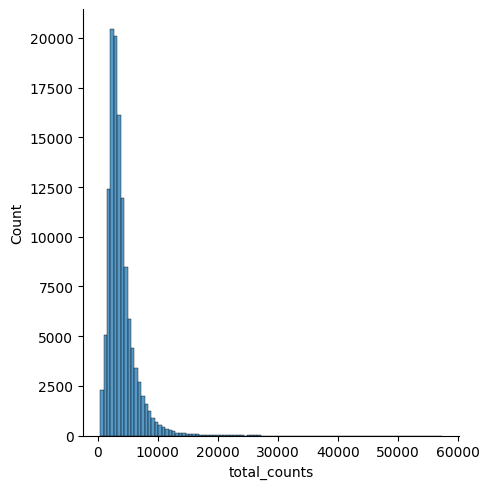

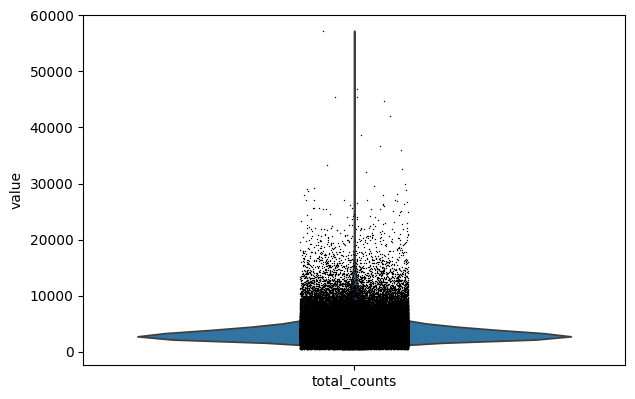

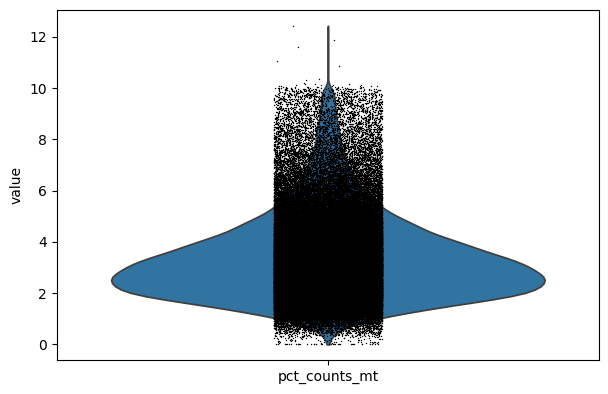

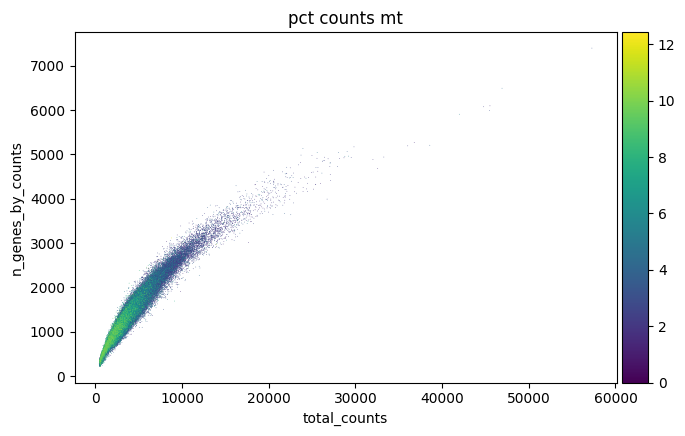

In [ ]:
p1 = sns.displot(combined_data.obs["total_counts"], bins=100, kde=False)
sc.pl.violin(combined_data, 'total_counts')
p2 = sc.pl.violin(combined_data, "pct_counts_mt")
p3 = sc.pl.scatter(combined_data, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
combined_data = combined_data[combined_data.obs['pct_counts_mt'] <= 8] # filter cells with high mitochondrial content

In [ ]:
sc.pp.filter_cells(combined_data, max_counts=150000) # filter cells with too many counts

/software/cellgen/team361/am74/envs/pertpy/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


/tmp/ipykernel_968620/3987137127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60)


<Axes: xlabel='n_genes'>

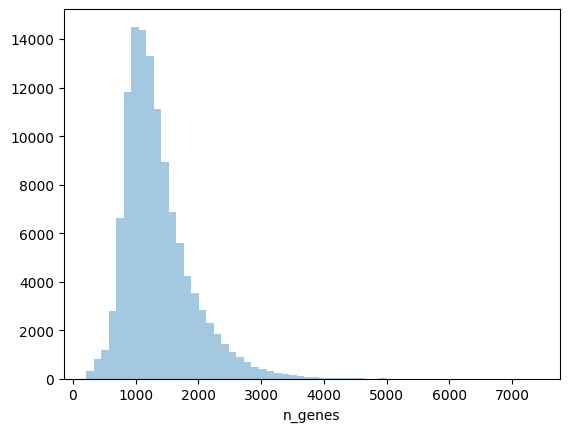

In [ ]:
combined_data.obs['n_genes'] = (combined_data.X > 0).sum(1) # calculate number of genes per cell
sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60) # visualize number of genes per cell

In [ ]:
sc.pp.filter_genes(combined_data, min_cells=20) # filter genes expressed in less than 20 cells
print('Number of genes after cell filter: {:d}'.format(combined_data.n_vars)) 

Number of genes after cell filter: 19186


In [ ]:
combined_data.obs['batch'] = combined_data.obs['batch'].cat.rename_categories({
    '0': 'T cell lineage',
    '1': 'B cell lineage',
    '2': 'Myeloid lineage'
})

In [18]:
combined_data.obs['final_anno'].value_counts()

final_anno
CD14mono                     23888
CD4_naive                    18268
CD8_naive                    13249
CD4_memory                   10259
CD8_EM                        8869
B_naive                       8185
Int.mono                      7229
NK_CD56dim                    4922
CD14mono_M1                   4129
gdT                           3325
MAIT                          2577
Treg                          2382
NKT                           2376
non-swtiched memory           1583
CD16mono                      1213
switched memory               1158
CD8_CM                        1004
DC2                            972
Platelet                       862
NK_CD56bright                  856
pDC                            696
DC3                            488
non-switched memory/CD11c      301
HSPC                           227
plasma_IgA                     160
DC1                             60
plasma_dividing                 50
plasma_IgG                      31
ASDC     

In [ ]:
combined_data.X.max() # check max counts after filtering

2717.0

In [ ]:
combined_data.obs['cell_type'] = combined_data.obs['final_anno'] # set cell_type based on final_anno

In [21]:
combined_data.obs['patient_id']

AAACCTGAGACAAAGG-1-0    IVLPS01_Baseline
AAACCTGAGCGTTCCG-1-0    IVLPS01_Baseline
AAACCTGAGTGTTTGC-1-0    IVLPS01_Baseline
AAACCTGCAAACTGTC-1-0    IVLPS01_Baseline
AAACCTGCACAACGTT-1-0    IVLPS01_Baseline
                              ...       
TTTGGTTTCGGAATCT-1-2         IVLPS12_10h
TTTGTCAAGGCATGTG-1-2         IVLPS12_10h
TTTGTCACAAAGGAAG-1-2         IVLPS12_10h
TTTGTCATCAACACTG-1-2         IVLPS12_10h
TTTGTCATCACAACGT-1-2         IVLPS12_10h
Name: patient_id, Length: 119360, dtype: category
Categories (23, object): ['IVLPS01_10h', 'IVLPS01_6h', 'IVLPS01_90min', 'IVLPS01_Baseline', ..., 'IVLPS06_Baseline', 'IVLPS12_10h', 'IVLPS12_6h', 'IVLPS12_90min']

In [22]:
combined_data.obs['donor_id'] = combined_data.obs['patient_id'].copy()

In [23]:
combined_data.obs['time_after_LPS']

AAACCTGAGACAAAGG-1-0     0m
AAACCTGAGCGTTCCG-1-0     0m
AAACCTGAGTGTTTGC-1-0     0m
AAACCTGCAAACTGTC-1-0     0m
AAACCTGCACAACGTT-1-0     0m
                       ... 
TTTGGTTTCGGAATCT-1-2    10h
TTTGTCAAGGCATGTG-1-2    10h
TTTGTCACAAAGGAAG-1-2    10h
TTTGTCATCAACACTG-1-2    10h
TTTGTCATCACAACGT-1-2    10h
Name: time_after_LPS, Length: 119360, dtype: category
Categories (4, object): ['0m', '10h', '6h', '90m']

In [24]:
combined_data.obs['time_after_LPS'] = combined_data.obs['time_after_LPS'].cat.rename_categories({
    '0m': 'normal',
    '10h': '10h_LPS',
    '6h': '6h_LPS',
    '90m': '90m_LPS'
})


In [25]:
combined_data.obs['time_after_LPS']

AAACCTGAGACAAAGG-1-0     normal
AAACCTGAGCGTTCCG-1-0     normal
AAACCTGAGTGTTTGC-1-0     normal
AAACCTGCAAACTGTC-1-0     normal
AAACCTGCACAACGTT-1-0     normal
                         ...   
TTTGGTTTCGGAATCT-1-2    10h_LPS
TTTGTCAAGGCATGTG-1-2    10h_LPS
TTTGTCACAAAGGAAG-1-2    10h_LPS
TTTGTCATCAACACTG-1-2    10h_LPS
TTTGTCATCACAACGT-1-2    10h_LPS
Name: time_after_LPS, Length: 119360, dtype: category
Categories (4, object): ['normal', '10h_LPS', '6h_LPS', '90m_LPS']

In [26]:
combined_data.obs['study'] = 'Private_Data_Emily'

In [27]:
combined_data.obs['tissue'] = 'blood'

In [28]:
combined_data

AnnData object with n_obs × n_vars = 119360 × 19186
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

In [29]:
combined_data.obs['age'].value_counts()

age
23.0    29443
37.0    29386
32.0    21621
36.0    18532
29.0    15735
24.0     4643
Name: count, dtype: int64

In [ ]:
def age_to_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 0:
        # Prenatal age, optional handling
        return 'Prenatal'
    elif age <= 18:
        return 'Childhood'
    elif 18 < age <= 25:
        return 'Young Adult'
    elif 26 <= age <= 64:
        return 'Adult'
    elif age >= 65:
        return 'Old'
    else:
        return 'Unknown'

combined_data.obs['development_stage'] = combined_data.obs['age'].apply(age_to_group)

# Optionally convert to categorical with order:
combined_data.obs['development_stage'] = pd.Categorical(
    combined_data.obs['development_stage'],
    categories=['Prenatal', 'Childhood', 'Young Adult', 'Adult', 'Old', 'Unknown'],
    ordered=True
)


In [31]:
combined_data.obs['development_stage'].value_counts()

development_stage
Adult          85274
Young Adult    34086
Childhood          0
Prenatal           0
Old                0
Unknown            0
Name: count, dtype: int64

In [ ]:
ref = pd.read_csv("../../../../Ensembl_symbol_Human_(GRCh38.p14)/mart_export.txt")  

In [33]:
ref

,HGNC symbol,Gene stable ID
0,MT-TF,ENSG00000210049
1,MT-RNR1,ENSG00000211459
2,MT-TV,ENSG00000210077
3,MT-RNR2,ENSG00000210082
4,MT-TL1,ENSG00000209082
...,...,...
86363,SNHG12,ENSG00000197989
86364,TAF12-DT,ENSG00000229388
86365,NaN,ENSG00000289291
86366,RNU11,ENSG00000274978


In [ ]:
# Current gene symbols from var_names
gene_symbols = combined_data.var_names.to_list()

# Create mapping: symbol -> Ensembl ID
symbol_to_ensembl = dict(zip(ref['HGNC symbol'], ref['Gene stable ID']))

# Map gene symbols to Ensembl IDs (or None if not found)
ensembl_ids = [symbol_to_ensembl.get(gene, None) for gene in gene_symbols]

# Create a mask to keep only genes with Ensembl IDs starting with "ENSG"
keep_mask = [ensembl is not None and ensembl.startswith("ENSG") for ensembl in ensembl_ids]

# Filter var and var_names accordingly
combined_data = combined_data[:, keep_mask].copy()  # subset cells and genes

# Update var_names to Ensembl IDs for kept genes
combined_data.var['ensembl_id'] = [ensembl_ids[i] for i, keep in enumerate(keep_mask) if keep]
combined_data.var_names = combined_data.var['ensembl_id'].values


In [38]:
combined_data.var['gene_symbol'] = combined_data.var['gene_ids']

In [39]:
combined_data.X.max()

2672.0

In [ ]:
if hasattr(combined_data.X, 'sum'):
    combined_data.obs['n_counts'] = np.ravel(combined_data.X.sum(axis=1))
else:
    combined_data.obs['n_counts'] = combined_data.X.sum(axis=1)


In [43]:
combined_data.obs['cell_type']

AAACCTGAGACAAAGG-1-0           NKT
AAACCTGAGCGTTCCG-1-0     CD8_naive
AAACCTGAGTGTTTGC-1-0    CD4_memory
AAACCTGCAAACTGTC-1-0           NKT
AAACCTGCACAACGTT-1-0     CD4_naive
                           ...    
TTTGGTTTCGGAATCT-1-2      Int.mono
TTTGTCAAGGCATGTG-1-2      Int.mono
TTTGTCACAAAGGAAG-1-2      CD14mono
TTTGTCATCAACACTG-1-2      CD14mono
TTTGTCATCACAACGT-1-2      CD14mono
Name: cell_type, Length: 119360, dtype: category
Categories (30, object): ['ASDC', 'B_naive', 'CD4_memory', 'CD4_naive', ..., 'plasma_IgG', 'plasma_IgM', 'plasma_dividing', 'switched memory']

In [ ]:
combined_data.write_h5ad('./raw_data_LPS_Private_Haniffa_lab.h5ad') # save the processed data

## 1.3. Concatenation of public and preprocessed prived data

In [2]:
adata1 = sc.read('./Private_emily/raw_data_LPS_Private_Haniffa_lab.h5ad')

/nfs/users/nfs_a/am74/.cache/pypoetry/virtualenvs/cytomeister-AO4Zveyp-py3.10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
adata2 = sc.read('./Public_Emily/Public_LPS_PP.h5ad')

In [ ]:
# Make var_names unique to avoid conflicts during concatenation
adata2.var_names_make_unique()
adata1.var_names_make_unique()

In [ ]:
# Concatenate the two datasets
adata = adata1.concatenate(adata2)

/tmp/ipykernel_983311/3094885911.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata1.concatenate(adata2)


In [ ]:
adata # check the merged data

AnnData object with n_obs × n_vars = 224150 × 13826
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

In [ ]:
adata.obs['time_after_LPS'].value_counts() # check time points available

time_after_LPS
normal     148742
6h_LPS      43810
10h_LPS     20890
90m_LPS     10708
Name: count, dtype: int64

In [ ]:
adata.obs['cell_type'].value_counts() # check cell types available

cell_type
CD14mono                     23888
CD4_naive                    18268
B_naive                      15093
CD4.Naive                    13829
NK_16hi                      13473
CD8_naive                    13249
CD4_memory                   10259
CD8_EM                        8869
gdT                           8273
CD8.Naive                     8105
CD4.CM                        7505
Int.mono                      7229
CD83_CD14_mono                6772
CD8.TE                        6501
CD4.IL22                      6379
MAIT                          6042
CD8.EM                        5734
NK_CD56dim                    4922
CD14mono_M1                   4129
CD14_mono                     3774
NKT                           3240
CD16_mono                     3007
Treg                          2457
Platelets                     2363
NK_56hi                       2190
DC2                           2024
non-swtiched memory           1583
DC3                           1463
B_switched

In [9]:
# Define a mapping dictionary for renaming
cell_type_mapping = {
    # Monocytes
    "CD14mono": "CD14 monocytes",
    "CD14_mono": "CD14 monocytes",
    "CD83_CD14_mono": "CD14 monocytes",
    "CD14mono_M1": "CD14 monocytes",
    "CD16_mono": "CD16 monocytes",
    "CD16mono": "CD16 monocytes",
    "C1_CD16_mono": "CD16 monocytes",
    # CD4 T cells
    "CD4_naive": "CD4+ T cells",
    "CD4.Naive": "CD4+ T cells",
    "CD4_memory": "CD4+ T cells",
    "CD4.CM": "CD4+ T cells",
    "CD4.Tfh": "CD4+ T cells",
    "CD4.Th1": "CD4+ T cells",
    "CD4.IL22": "CD4+ T cells",
    "CD4.EM": "CD4+ T cells",
    # CD8 T cells
    "CD8_naive": "CD8+ T cells",
    "CD8.Naive": "CD8+ T cells",
    "CD8_EM": "CD8+ T cells",
    "CD8.EM": "CD8+ T cells",
    "CD8_CM": "CD8+ T cells",
    "CD8.TE": "CD8+ T cells",
    "CD8.Prolif": "CD8+ T cells",
    # NK cells
    "NK_16hi": "NK",
    "NK_56hi": "NK",
    "NK_CD56dim": "NK",
    "NK_CD56bright": "NK",
    "NK_prolif": "NK",
    # B cells
    "B_naive": "B cell",
    "B_switched_memory": "B cell",
    "non-swtiched memory" : "B cell",
    "switched memory": "B cell",
    "B_non-switched_memory": "B cell",
    "non-switched memory": "B cell",
    "non-switched memory/CD11c": "B cell",
    "B_immature": "B cell",
    "B_exhausted": "B cell",
    # Plasma cells
    "Plasma_cell_IgA": "plasma cell",
    "plasma_IgA": "plasma cell",
    "Plasma_cell_IgG": "plasma cell",
    "plasma_IgG": "plasma cell",
    "Plasma_cell_IgM": "plasma cell",
    "plasma_IgM": "plasma cell",
    "Plasmablast": "plasma cell",
    "plasma_dividing": "plasma cell",
    # Others
    "Platelets": "platelet",
    "Platelet": "platelet",
    "Treg": "regulatory T cell",
    "MAIT": "mucosal invariant T cell",
    "gdT": "gamma-delta T cell",
    "NKT": "NKT",
    "pDC": "Plasmocytoid dendritic cell",
    "DC1": "Dendritic cells",
    "DC2": "Dendritic cells",
    "DC3": "Dendritic cells",
    "ASDC": "ASDC",
    "Int.mono": "CD14 monocytes",
    "RBC": "Red_Blood_Cell",
    "HSPC": "hematopoietic stem cell",
    "HSC_erythroid": "HSC_Erythroid",
    "HSC_CD38pos": "HSC_CD38pos",
    "ILC1_3": "ILC1_3",
}

# Apply the mapping to adata.obs['cell_type']
adata.obs['cell_type_harmonized'] = adata.obs['cell_type'].map(cell_type_mapping).fillna(adata.obs['cell_type'])

# Verify the new counts
print(adata.obs['cell_type_harmonized'].value_counts())

cell_type_harmonized
CD4+ T cells                   57329
CD14 monocytes                 45792
CD8+ T cells                   43532
NK                             21662
B cell                         21477
gamma-delta T cell              8273
mucosal invariant T cell        6042
CD16 monocytes                  4418
Dendritic cells                 3651
NKT                             3240
platelet                        3225
regulatory T cell               2457
Plasmocytoid dendritic cell     1374
plasma cell                      779
Red_Blood_Cell                   301
hematopoietic stem cell          227
ILC1_3                           213
HSC_Erythroid                     74
HSC_CD38pos                       61
ASDC                              23
Name: count, dtype: int64


In [ ]:
# Get unique timepoints
all_timepoints = adata.obs['time_after_LPS'].unique()

# Group by cell_type and get unique timepoints per cell type
cell_type_timepoints = (
    adata.obs
    .groupby('cell_type_harmonized')['time_after_LPS']
    .unique()
    .apply(list)
)

# Find cell types that do not appear in all timepoints
missing_in_any_timepoint = [
    ct for ct in cell_type_timepoints.index 
    if not set(all_timepoints).issubset(set(cell_type_timepoints[ct]))
]

print("Cell types not present in all timepoints:", missing_in_any_timepoint)

Cell types not present in all timepoints: ['ASDC', 'HSC_CD38pos', 'HSC_Erythroid', 'ILC1_3', 'Red_Blood_Cell']


In [4]:
adata = sc.read('./full_lps.h5ad')

In [5]:
cell_types_to_remove = ['ASDC', 'HSC_CD38pos', 'HSC_Erythroid', 'ILC1_3', 'Red_Blood_Cell']
keep_mask = ~adata.obs['cell_type_harmonized'].isin(cell_types_to_remove)
adata_filtered = adata[keep_mask, :].copy() 

In [6]:
adata_filtered.obs['cell_type_harmonized'].value_counts()

cell_type_harmonized
CD4+ T cells                   57329
CD14 monocytes                 45792
CD8+ T cells                   43532
NK                             21662
B cell                         21477
gamma-delta T cell              8273
mucosal invariant T cell        6042
CD16 monocytes                  4418
Dendritic cells                 3651
NKT                             3240
platelet                        3225
regulatory T cell               2457
Plasmocytoid dendritic cell     1374
plasma cell                      779
hematopoietic stem cell          227
Name: count, dtype: int64

In [7]:
len(set(adata_filtered.obs['cell_type_harmonized']))

15

In [8]:
adata_filtered.X.max()

np.float32(4066.0)

In [ ]:
adata_filtered.write_h5ad('./full_lps.h5ad') # save the final processed data